In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score,r2_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer

In [2]:
df=pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [3]:
df.dropna(inplace=True)

In [4]:
df.shape

(714, 3)

In [5]:
df.head(5)

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [6]:
X=df.drop(columns=['Survived'])
y=df['Survived']

In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
X_train.head(2)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [9]:
clf=DecisionTreeClassifier()


In [10]:
clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)

In [11]:
accuracy_score(y_test,y_pred)

0.6223776223776224

In [12]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6288928012519561)

 # Now we use our descretizer

In [13]:
kbin_fare=KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')
kbin_age=KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')

In [14]:
trf=ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [15]:
X_train_trf=trf.fit_transform(X_train)
X_test_trf=trf.fit_transform(X_test)

In [16]:
output=pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
    
})

In [17]:
output['age_labels'] = pd.cut(x=X_train['Age'],
bins=trf.named_transformers_['first'].bin_edges_[0].tolist())

output['fare_labels'] = pd.cut (x=X_train['Fare'],
bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [18]:
output.sample(5)


,age,age_trf,fare,fare_trf,age_labels,fare_labels
628,26.0,4.0,7.8958,2.0,"(24.0, 28.0]","(7.742, 7.925]"
452,30.0,5.0,27.7500,6.0,"(28.0, 30.0]","(22.525, 29.125]"
512,36.0,7.0,26.2875,6.0,"(35.0, 39.0]","(22.525, 29.125]"
809,33.0,6.0,53.1000,8.0,"(30.0, 35.0]","(39.0, 57.979]"
850,4.0,0.0,31.2750,7.0,"(1.0, 11.0]","(29.125, 39.0]"


In [19]:
clf=DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2=clf.predict(X_test_trf)

In [20]:
accuracy_score(y_test,y_pred)

0.6223776223776224

In [21]:
X_trf=trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6345070422535211)

In [22]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()
    

0.626056338028169


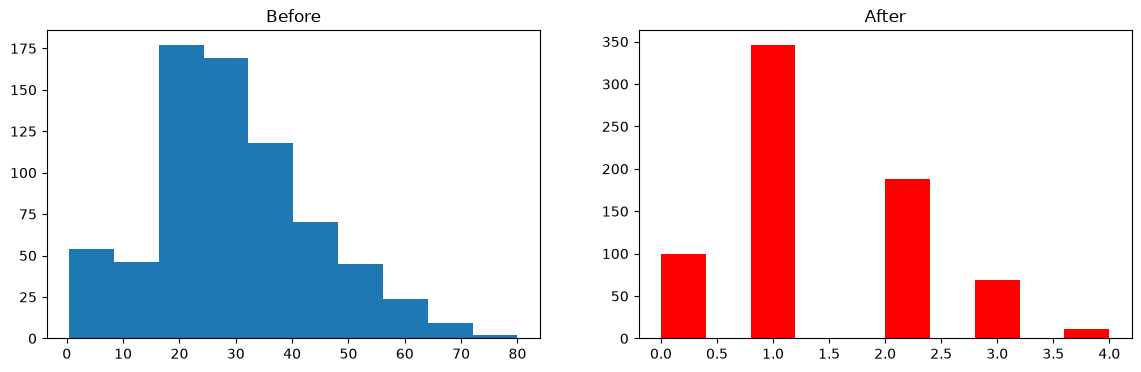

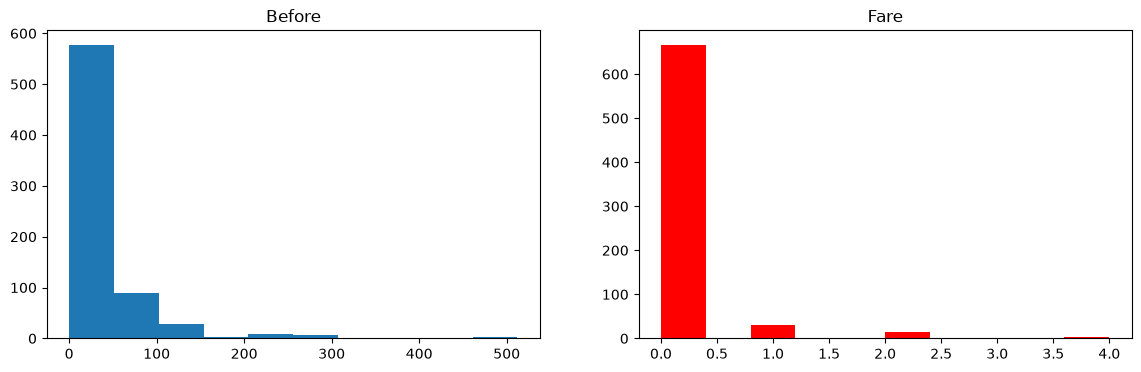

In [23]:
discretize(5,'uniform')